In [2]:
script = False
cluster = False

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from astropy.io import fits
from astropy.visualization import make_lupton_rgb

from PIL import Image, ImageOps
from memory_profiler import memory_usage
import random
import os
import gc
import joblib

if(script):
    from tqdm import tqdm
else: 
    from tqdm.notebook import tqdm

plt.style.use('dark_background')

In [3]:
def seed_everything(seed):
    """
    Seeds basic parameters for reproductibility of results
    Arguments:
        seed {int} -- Number of the seed
    """
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [4]:
class ImageDataset(Dataset):
    """Dataset of Images, Data and Labels"""

    def __init__(self, images, data, labels, transform=None):
        """
        Create a PyTorch dataset from an array of images
		and an array of labels
        """
        super().__init__()
        self.images = images
        self.data = data
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        #return python image given the index
        image = self.images[idx]
        """
        #Plotting with Astropy and saving as png (not used right now)
        print('Astropy')
        rgb = make_lupton_rgb(image[2], image[1], image[0], Q=11., stretch=40.)
        plt.imshow(rgb, aspect='equal')
        plt.savefig('Image.png', bbox_inches='tight')
        plt.close()
        new_image = Image.open('Image.png')
        return(new_image)
        """
        #new_image = np.empty((3, 45, 45))
        #new_image[0], new_image[1], new_image[2] =  self.normalize_image(image)
        #new_image = new_image.transpose(1,2,0)
        new_image = image.transpose(1,2,0) 
        new_image = (new_image - new_image.min()) / (new_image.max() - new_image.min())
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")
        
        label = self.labels[idx]
        data_point = self.data.iloc[idx].to_dict()
        sample = {'image': self.transform(new_image), 'label': label, 'img': image, 'data': data_point}
        return sample
    
    def normalize_image(self, image):
        image_g = (image[0]-np.mean(image[0]))/ np.std(image[0])
        image_r = (image[1]-np.mean(image[1]))/ np.std(image[1])
        image_i = (image[2]-np.mean(image[2]))/ np.std(image[2])

        image_g = (image_g-np.min(image_g))/ (np.max(image_g) - np.min(image_g))
        image_r = (image_r-np.min(image_r))/ (np.max(image_r) - np.min(image_r))
        image_i = (image_i-np.min(image_i))/ (np.max(image_i) - np.min(image_i))
        return(image_i, image_r, image_g)
    
    def plot_image(self, idx):
        image = images[idx]
        new_image = np.empty((3, 45, 45))
        new_image[0], new_image[1], new_image[2] =  self.normalize_image(image)
        new_image = new_image.transpose(1,2,0)
        new_image = Image.fromarray(np.uint8(255*new_image)).convert("RGB")
        
        plt.figure(figsize=(12,4)) 
        
        plt.subplot(1,2,1)
        plt.imshow(np.asarray(new_image))
        plt.axis('off')
        
        plt.subplot(1,2,2)
        rgb = make_lupton_rgb(image[2], image[1], image[0], Q=11., stretch=40.)
        plt.imshow(rgb, aspect='equal')
        plt.axis('off')
        
        plt.show()


In [5]:
def make_train_test_datasets(images, data, labels, test_size=0.2, transform=None):
    """
	Make training and testing datasets
	
	Args:
	    images: 3D array of all images
        labels: 1D array of the labels for each image
        test_size: the fraction of the images to use as the test dataset
		transform: the PyTorch transformation to apply to the data
		
	Returns
	    train_dataset: An instance of the ImageDataset Class for training
		test_dataset: An instance of the ImageDataset Class for testing
	"""

    # Shuffle and split data
    y = labels
    train_images, test_images, train_data, test_data, train_labels, test_labels = train_test_split(
        images, data, labels, test_size=test_size, random_state=6)
    
    # Create a PyTorch Dataset
    return (ImageDataset(train_images, train_data, train_labels, transform=transform),
            ImageDataset(test_images, test_data, test_labels, transform=transform))

In [10]:
seed_everything(9)

if(cluster):
    path = '/data/des90.a/data/sgonzal/training_data/' #DES cluster
    path = '' #CHTC
    filename = 'simulation_file.fits'
else:
    path = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/Regression/simulations/Data/fit_files/' #local
    filename = '1000_simu.fits'
    
#200
npos = 1000
num_workers = 0
num_epochs = 10

hdu_list = fits.open(path + filename)
print(len(hdu_list[1].data))
idx = random.sample(range(len(hdu_list[1].data)), npos)
images_dataset  = hdu_list[1].data[idx,:].astype(np.float32)
print(images_dataset.shape)
print("Max pixel value:", np.max(images_dataset))
print("Min pixel value:", np.min(images_dataset))
data_dataset = pd.DataFrame(hdu_list[2].data[:][idx])
data_dataset = data_dataset.drop('TILENAME', axis=1)
hdu_list.close()

new_data = data_dataset[data_dataset['e1_lens_light'] > -2] # Removing artifacts
images_dataset = images_dataset[new_data.index]
data_dataset = new_data.reset_index(drop=True)
labels_dataset = data_dataset[['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens', 'center_y_lens', 'R_sersic_source_light', 'n_sersic_source_light',
       'e1_source_light', 'e2_source_light', 'center_x_source', 'center_y_source', 'R_sersic_lens_light', 'e1_lens_light', 'e2_lens_light']] #Labels to predict

print(labels_dataset.columns)
labels_dataset = torch.tensor(labels_dataset.values, dtype=torch.float32)

transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))])

print(images_dataset.shape)

1000
(1000, 3, 45, 45)
Max pixel value: 3421.1458
Min pixel value: -109.100044
Index(['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens',
       'center_y_lens', 'R_sersic_source_light', 'n_sersic_source_light',
       'e1_source_light', 'e2_source_light', 'center_x_source',
       'center_y_source', 'R_sersic_lens_light', 'e1_lens_light',
       'e2_lens_light'],
      dtype='str')
(994, 3, 45, 45)


In [6]:
data_dataset.head()

,Y6_COADD_OBJECT_ID,HPIX_16384,HPIX_4096,DNF_ZMEAN_SOF,RA,DEC,FLUX_RADIUS_G,FLUX_RADIUS_R,FLUX_RADIUS_I,FLUX_RADIUS_Z,...,R_sersic_source_light,n_sersic_source_light,e1_source_light,e2_source_light,center_x_source,center_y_source,R_sersic_lens_light,n_sersic_lens_light,e1_lens_light,e2_lens_light
0,1243922494,1170882703,73180168,0.321904,31.969639,2.125371,6.853356,6.309624,6.104346,6.210601,...,1.098306,2.838410,0.077411,0.092158,-0.643906,-1.450849,1.807230,1.404194,-0.025761,-0.087985
1,1298616789,1168688872,73043054,0.648051,23.935191,-0.430711,4.844542,4.588861,4.331135,4.405827,...,0.708217,2.939804,-0.074122,0.039477,-0.255199,0.016854,1.277506,2.198294,-0.116809,0.029799
2,930221869,1251425619,78214101,0.568212,324.918844,0.520463,4.177025,3.824084,3.661597,3.870771,...,0.550328,0.797261,-0.082019,0.097776,-0.705211,-0.723097,1.101482,0.524569,0.045849,0.087371
3,1330938343,2414011538,150875721,0.514677,41.382495,-5.720250,4.092360,4.139807,4.112240,4.101294,...,0.765622,2.262811,0.015537,-0.044640,-0.232950,0.017522,1.079155,3.398818,-0.140466,-0.011279
4,1075488170,1183147779,73946736,0.605790,7.998106,-2.383262,7.841796,5.579764,5.073406,4.838587,...,0.816772,5.563921,0.011775,0.025398,0.696262,-0.215053,2.067882,1.144498,0.055528,-0.033126


In [7]:
train_dataset, other_dataset = make_train_test_datasets(images_dataset, data_dataset, labels_dataset, test_size=0.2, transform=transform)
#Standardizing the parameters
scaler_y = StandardScaler()
train_dataset.labels = torch.tensor(scaler_y.fit_transform(train_dataset.labels.numpy()), dtype=torch.float32) #Fitting on training sample
other_dataset.labels = torch.tensor(scaler_y.transform(other_dataset.labels.numpy()), dtype=torch.float32) #Transforming the other sample
joblib.dump(scaler_y, 'scaler_y.joblib') #Save scaler for inference 

valid_dataset, test_dataset = make_train_test_datasets(other_dataset.images, other_dataset.data, other_dataset.labels, test_size=0.5, transform=transform)
print('Len train dataset: {}, len test dataset: {}'.format(len(train_dataset), len(test_dataset)))

Len train dataset: 795, len test dataset: 100


In [8]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=20, num_workers=num_workers, shuffle=True)
valid_loader = torch.utils.data.DataLoader(dataset=valid_dataset, batch_size=20, num_workers=num_workers, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=20, num_workers=num_workers, shuffle=True)
torch.save(test_loader, 'test_loader.pth')

In [9]:
class EfficientNetClass(nn.Module):
    
    def __init__(self, n_classes, pretrained=False):
        
        super(EfficientNetClass, self).__init__()
        
        if(not cluster):
            self.model = EfficientNet.from_pretrained('efficientnet-b0',  num_classes=n_classes)
            torch.save(self.model.state_dict(), 'initial_model.pt')
        else:
            self.model = EfficientNet.from_name('efficientnet-b0',  num_classes=n_classes)
            self.model.load_state_dict(torch.load('initial_model.pt', weights_only=True))

    def forward(self, x):

        x = self.model(x)

        return x

    def train_one_epoch(self, train_loader, criterion, optimizer, device):
        # keep track of training loss
        epoch_loss = 0.0
        epoch_accuracy = 0.0

        ###################
        # train the model #
        ###################

        self.model.train()

        for i, sample in enumerate(tqdm(train_loader)):

            data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']
            
            # move tensors to GPU if CUDA is available
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()

            # clear the gradients of all optimized variables
            optimizer.zero_grad()
            # forward pass: compute predicted outputs by passing inputs to the model
            output = self.forward(data)
            
            # calculate the batch loss
            loss = criterion(output, target)
            # backward pass: compute gradient of the loss with respect to model parameters
            loss.backward()
            
            # Calculate Accuracy
            accuracy = loss # Not needed AKDMFMAKDFMAKFGOIAJEROFMAOIMGOIAJMROGKMAOFMGAOFDLGMAKLFMGK
            
            # update training loss and accuracy
            epoch_loss += loss
            epoch_accuracy += accuracy

            optimizer.step()

        return epoch_loss / len(train_loader.dataset), epoch_accuracy / len(train_loader.dataset)

    def validate_one_epoch(self, valid_loader, criterion, device):
        # keep track of validation loss
        valid_loss = 0.0
        valid_accuracy = 0.0

        ######################
        # validate the model #
        ######################
        self.model.eval()
        for i, sample in enumerate(tqdm(valid_loader)):
            data, target, sample_img, sample_data = sample['image'], sample['label'] , sample['img'], sample['data']
            
            # move tensors to GPU if CUDA is available
            if device.type == "cuda":
                data, target = data.cuda(), target.cuda()

            with torch.no_grad():
                # forward pass: compute predicted outputs by passing inputs to the model
                output = self.model(data)
                # calculate the batch loss
                loss = criterion(output, target)
                # Calculate Accuracy
                accuracy = loss # TO UPDATE ADMFKAMDKFMAKDMFKAJDKGJNAOIERJGOIMRGOIJROITJIOJRGIOSJIFGJMSOIRGJISRJI
                # update average validation loss and accuracy
                valid_loss += loss
                valid_accuracy += accuracy
        
        return valid_loss / len(valid_loader.dataset), valid_accuracy / len(valid_loader.dataset)

In [10]:
model = EfficientNetClass(n_classes=14, pretrained=True)

criterion = torch.nn.HuberLoss() #nn.CrossEntropyLoss() #nn.BCELoss() torch.nn.MSELoss()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model.to(device)

learning_rate = 0.00007 #0.001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Loaded pretrained weights for efficientnet-b0
cpu


In [11]:
def fit_tpu(model, name_model, epochs, device, criterion, optimizer, train_loader, valid_loader=None):
    
    best_val_loss = float('inf') # track of best loss
    model_data = pd.DataFrame()

    # keeping track of losses as it happen
    train_losses = []
    valid_losses = []
    train_accs = []
    valid_accs = []

    for epoch in range(1, epochs + 1):
        gc.collect()
        
        print(f"{'=' * 100}")
        print(f"EPOCH {epoch} - TRAINING...")
        train_loss, train_acc = model.train_one_epoch(train_loader, criterion, optimizer, device)
        print(f"\n\t[TRAIN] EPOCH {epoch} - LOSS: {train_loss}, ACCURACY: {train_acc}\n")
        train_losses.append(train_loss.cpu().data.numpy())
        train_accs.append(train_acc.cpu().data.numpy())
        gc.collect()

        # moves towards valid_loader
        print("start valid_loader")

        if valid_loader is not None:
            gc.collect()
            print(f"EPOCH {epoch} - VALIDATING...")
            valid_loss, valid_acc = model.validate_one_epoch(valid_loader, criterion, device)
            print(f"\t[VALID] LOSS: {valid_loss}, ACCURACY: {valid_acc}\n")
            valid_losses.append(valid_loss.cpu().data.numpy())
            valid_accs.append(valid_acc.cpu().data.numpy())
            gc.collect()
            
            if(valid_loss.cpu().data.numpy() < best_val_loss):
                setattr(model, 'loss_train', train_losses)
                setattr(model, 'loss_valid', valid_losses)
                setattr(model, 'train_acc', train_accs)
                setattr(model, 'validation_acc', valid_accs)
                torch.save(model.state_dict(), name_model)
                best_val_loss = valid_loss.cpu().data.numpy()
                
    model_data['train_losses'] = train_losses
    model_data['valid_losses'] = valid_losses
    model_data['train_accs'] = train_accs
    model_data['valid_accs'] = valid_accs
    model_data.to_csv('Complete_model.csv', index=False)

In [12]:
def plot_performance(cnn):
    loss_train = [x.item() for x in cnn.loss_train]
    loss_valid = [x.item() for x in cnn.loss_valid]
    train_acc = [x.item() for x in cnn.train_acc]
    valid_acc = [x.item() for x in cnn.validation_acc]
    
    x = np.linspace(1,len(cnn.loss_train),len(cnn.loss_train))
    fig, (ax1, ax2) = plt.subplots(figsize=(16, 7), ncols=2)
    
    ax1.set_title('Losses')
    ax1.set_xlabel('Epoch')
    ax1.scatter(x, loss_train, color = 'skyblue', alpha = 0.8, label = 'Training loss')
    ax1.scatter(x, loss_valid, color = 'limegreen', alpha = 0.8,  label = 'Validation loss')
    ax1.legend()
    
    ax2.set_title('Performance. Max: {:.4f}%'.format(100*cnn.validation_acc[-1].item()))
    ax2.set_xlabel('Epoch')
    ax2.scatter(x, train_acc, color = 'skyblue', alpha = 0.8,  label = 'Training Accuracy')
    ax2.scatter(x, valid_acc, color = 'limegreen', alpha = 0.8,  label = 'Validation Accuracy')
    ax2.legend()
    
    if(script):
        plt.savefig('Performance.png', bbox_inches='tight')
        plt.close()
    else: 
        plt.show(block=True)

In [13]:
name_model = 'model_tmp.pt' #other, model
#                          model, name_model, epochs, device, criterion, optimizer, train_loader, valid_loader=None
mem_usage = memory_usage(( fit_tpu, (model, name_model, num_epochs, device, criterion, optimizer, train_loader, valid_loader)))


EPOCH 1 - TRAINING...


  0%|          | 0/40 [00:00<?, ?it/s]


	[TRAIN] EPOCH 1 - LOSS: 0.01696288213133812, ACCURACY: 0.01696288213133812

start valid_loader
EPOCH 1 - VALIDATING...


  0%|          | 0/5 [00:00<?, ?it/s]

	[VALID] LOSS: 0.017973577603697777, ACCURACY: 0.017973577603697777

EPOCH 2 - TRAINING...


...

	[VALID] LOSS: 0.015322568826377392, ACCURACY: 0.015322568826377392

EPOCH 10 - TRAINING...


  0%|          | 0/40 [00:00<?, ?it/s]


	[TRAIN] EPOCH 10 - LOSS: 0.009102938696742058, ACCURACY: 0.009102938696742058

start valid_loader
EPOCH 10 - VALIDATING...


  0%|          | 0/5 [00:00<?, ?it/s]

	[VALID] LOSS: 0.01463621947914362, ACCURACY: 0.01463621947914362



In [14]:
#print('Maximum memory usage: %s' % max(mem_usage))

In [15]:
path_exp = '' #''   testing,  'Exp/exp2/'
name = path_exp + 'model_tmp.pt'#'model.pt'#'other.pt' 

model.load_state_dict(torch.load(name, weights_only=True))
test_loader = DataLoader(test_dataset, batch_size=test_loader.batch_size, shuffle=False, num_workers=0)

print('Lowest validation loss (Mean Squared Error): {:.2f}'.format(100*model.loss_valid[-1].item()))

Lowest validation loss (Mean Squared Error): 1.46


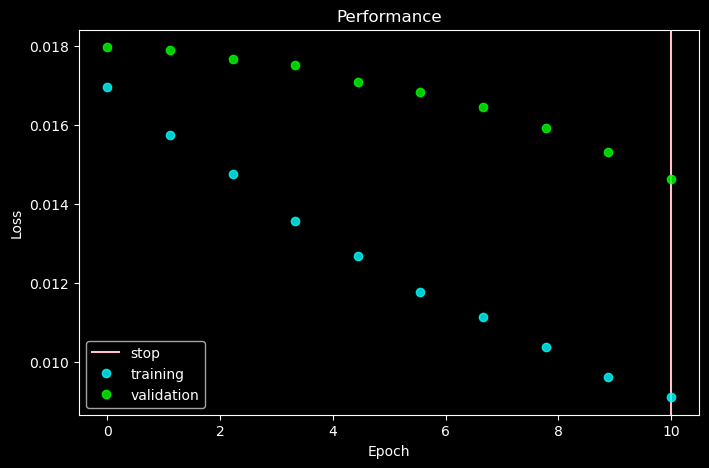

In [16]:
# Plotting complete training
data_model = pd.read_csv(path_exp + 'Complete_model.csv')

plt.figure(figsize=(8,5))
plt.xlabel('Epoch')
plt.ylabel('Loss')
x = np.linspace(0, len(data_model), len(data_model))
plt.title('Performance')
plt.axvline(x = len(model.loss_train), label='stop', color='#FFC0CB')
plt.plot(x, data_model['train_losses'].values, 'o', label='training', color='#00FFFF', alpha=0.8)
plt.plot(x, data_model['valid_losses'].values, 'o', label='validation', color='#00FF00', alpha=0.8)
plt.legend()

if(script):
    plt.savefig('Performance.png', bbox_inches='tight')
    plt.close()
else: 
    plt.show(block=True)

In [17]:
def testing_analysis(test_loader):
    predicted_data, true_data = [], []
    for i, sample in enumerate(tqdm(test_loader)):
        data, target, sample_img, sample_data = sample['image'], sample['label'], sample['img'], sample['data']
        
        if device.type == "cuda":
            data, target = data.cuda(), target.cuda()
        
        output = model.forward(data)
        predicted_data.append(pd.DataFrame(output.detach().cpu().numpy()))
        true_data.append(pd.DataFrame(target.cpu().numpy()))
    
    predicted_data = pd.concat(predicted_data, ignore_index=True)
    true_data = pd.concat(true_data, ignore_index=True)
        
    return(predicted_data, true_data)

In [18]:
test_dataset = test_loader.dataset
test_images, test_data = test_dataset.images, test_dataset.data
test_data = test_data.reset_index(drop=True)

predicted_data, true_data = testing_analysis(test_loader)

true_data = scaler_y.inverse_transform(true_data) #NEW LINE ASDFASDFASDFASDFASDFASDFASDFADSF
true_data = pd.DataFrame(true_data)
predicted_data = scaler_y.inverse_transform(predicted_data) #NEW LINE ASDFASDFASDFASDFASDFASDFASDFADSF
predicted_data = pd.DataFrame(predicted_data)

  0%|          | 0/5 [00:00<?, ?it/s]

In [19]:
names = ['EINSTEIN_RADIUS', 'e1_lens', 'e2_lens', 'center_x_lens', 'center_y_lens', 'R_sersic_source_light',
       'n_sersic_source_light', 'e1_source_light', 'e2_source_light', 'center_x_source', 'center_y_source', 
        'R_sersic_lens_light', 'e1_lens_light', 'e2_lens_light']
column_mapping = {old_column: new_column for old_column, new_column in enumerate(names)}
predicted_data.rename(columns=column_mapping, inplace=True)
true_data.rename(columns=column_mapping, inplace=True)

In [20]:
new_test_data = [] #pd.DataFrame(columns = true_data.columns)
for i in range(len(true_data)):
    closest_index = (test_data['EINSTEIN_RADIUS'] - true_data['EINSTEIN_RADIUS'].iloc[i]).abs().idxmin()
    closest_row = test_data.loc[closest_index]
    new_test_data.append(closest_row)
    #new_test_data = pd.concat(new_test_data, ignore_index=True)

new_test_data = pd.DataFrame(new_test_data, columns = true_data.columns)
test_data = new_test_data
test_images = test_images[test_data.index]
test_data = test_data.reset_index(drop=True)

for name in names:
    loss_value = list((predicted_data[name]-true_data[name])**2)
    column_name = 'loss_' + name
    test_data[column_name] = loss_value
    
test_data['pred_EINSTEIN_RADIUS'] = list(predicted_data['EINSTEIN_RADIUS'])

In [21]:
test_data.head()

,EINSTEIN_RADIUS,e1_lens,e2_lens,center_x_lens,center_y_lens,R_sersic_source_light,n_sersic_source_light,e1_source_light,e2_source_light,center_x_source,...,loss_R_sersic_source_light,loss_n_sersic_source_light,loss_e1_source_light,loss_e2_source_light,loss_center_x_source,loss_center_y_source,loss_R_sersic_lens_light,loss_e1_lens_light,loss_e2_lens_light,pred_EINSTEIN_RADIUS
0,2.344489,-0.240622,-0.240622,0.0,0.0,0.768487,5.335333,-0.171487,0.281577,-0.653334,...,1.185595e-03,1.739663,0.011905,0.066434,0.605574,1.425669,0.050454,0.001660,0.033103,2.283016
1,2.898458,-0.060934,-0.060934,0.0,0.0,0.852342,4.148680,0.264420,0.019042,-0.015038,...,4.764333e-03,2.565276,0.086845,0.000722,0.014310,0.262822,0.035807,0.000805,0.001747,2.508417
2,1.388341,-0.388722,-0.388722,0.0,0.0,0.751975,2.255296,0.001105,0.009071,0.260482,...,2.316571e-04,2.238083,0.001768,0.000024,0.015805,0.144384,0.219336,0.002794,0.050415,2.021483
3,5.865633,0.187447,0.187447,0.0,0.0,0.882450,4.610921,-0.036858,0.020570,-1.479215,...,8.474929e-07,0.941774,0.003503,0.003258,3.554828,0.038536,0.061604,0.036546,0.000134,3.443827
4,2.649019,-0.427434,-0.427434,0.0,0.0,0.689389,2.371759,-0.021430,0.000844,0.760648,...,9.274896e-03,0.706127,0.002415,0.001231,0.369722,0.091962,1.282978,0.000038,0.001104,3.200658


In [22]:
def make_plot_all(objects, title, data, Q, stretch, minimum):
    for i in range(len(objects)):
        if(i%7 == 0):
            plt.figure(figsize=(10,2))
            for j in range(7):
                if(i+j > len(objects)-1): break
                plt.subplot(1,7,j+1)
                #print(data['COADD_OBJECT_ID'].iloc[i+j]) 
                title = 'T:{:.1f}  P:{:.1f}'.format(data['EINSTEIN_RADIUS'].iloc[i+j], data['pred_EINSTEIN_RADIUS'].iloc[i+j])
                plt.title(title)
                rgb = make_lupton_rgb(objects[i+j][0], objects[i+j][1], objects[i+j][2], 
                                    Q=Q, stretch=stretch, minimum=minimum)
                plt.imshow(rgb, aspect='equal')
                plt.xticks([], [])
                plt.yticks([], []) 
            #plt.savefig(png_filepath + title + '.png', bbox_inches='tight')
            plt.show() 

worst


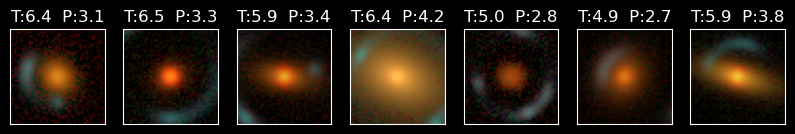

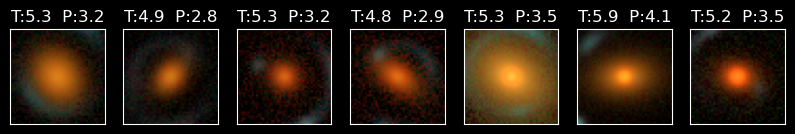

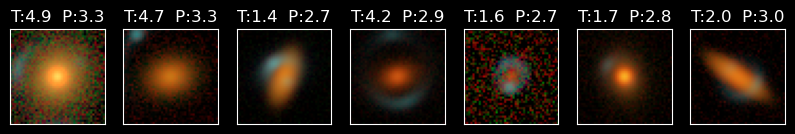

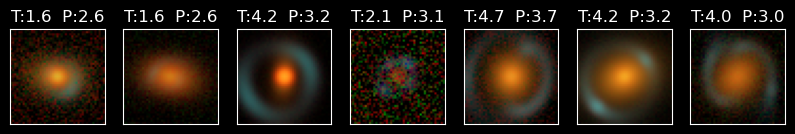

best


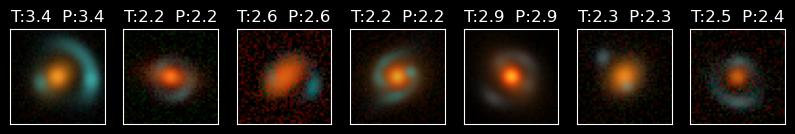

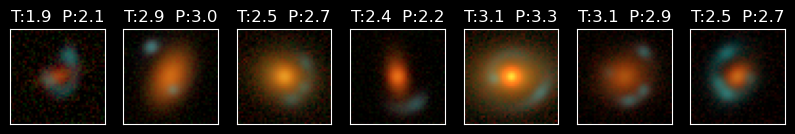

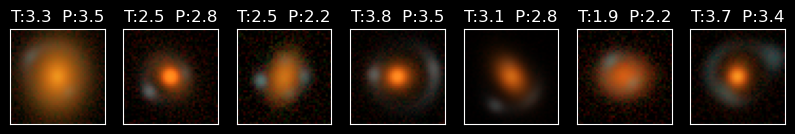

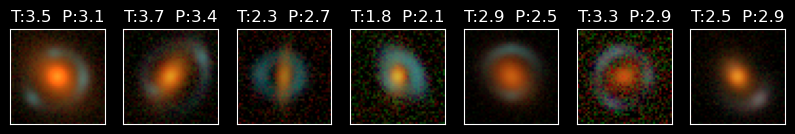

In [23]:
print('worst')
worst_data = test_data.nlargest(28, 'loss_EINSTEIN_RADIUS').sort_values(by='loss_EINSTEIN_RADIUS', ascending=False)
worst_images = test_images[worst_data.index]
make_plot_all(worst_images, 'title', worst_data, 9, 40, (0, 0, 0))

print('best')
worst_data = test_data.nsmallest(28, 'loss_EINSTEIN_RADIUS').sort_values(by='loss_EINSTEIN_RADIUS', ascending=True)
worst_images = test_images[worst_data.index]
make_plot_all(worst_images, 'title', worst_data, 9, 40, (0, 0, 0))

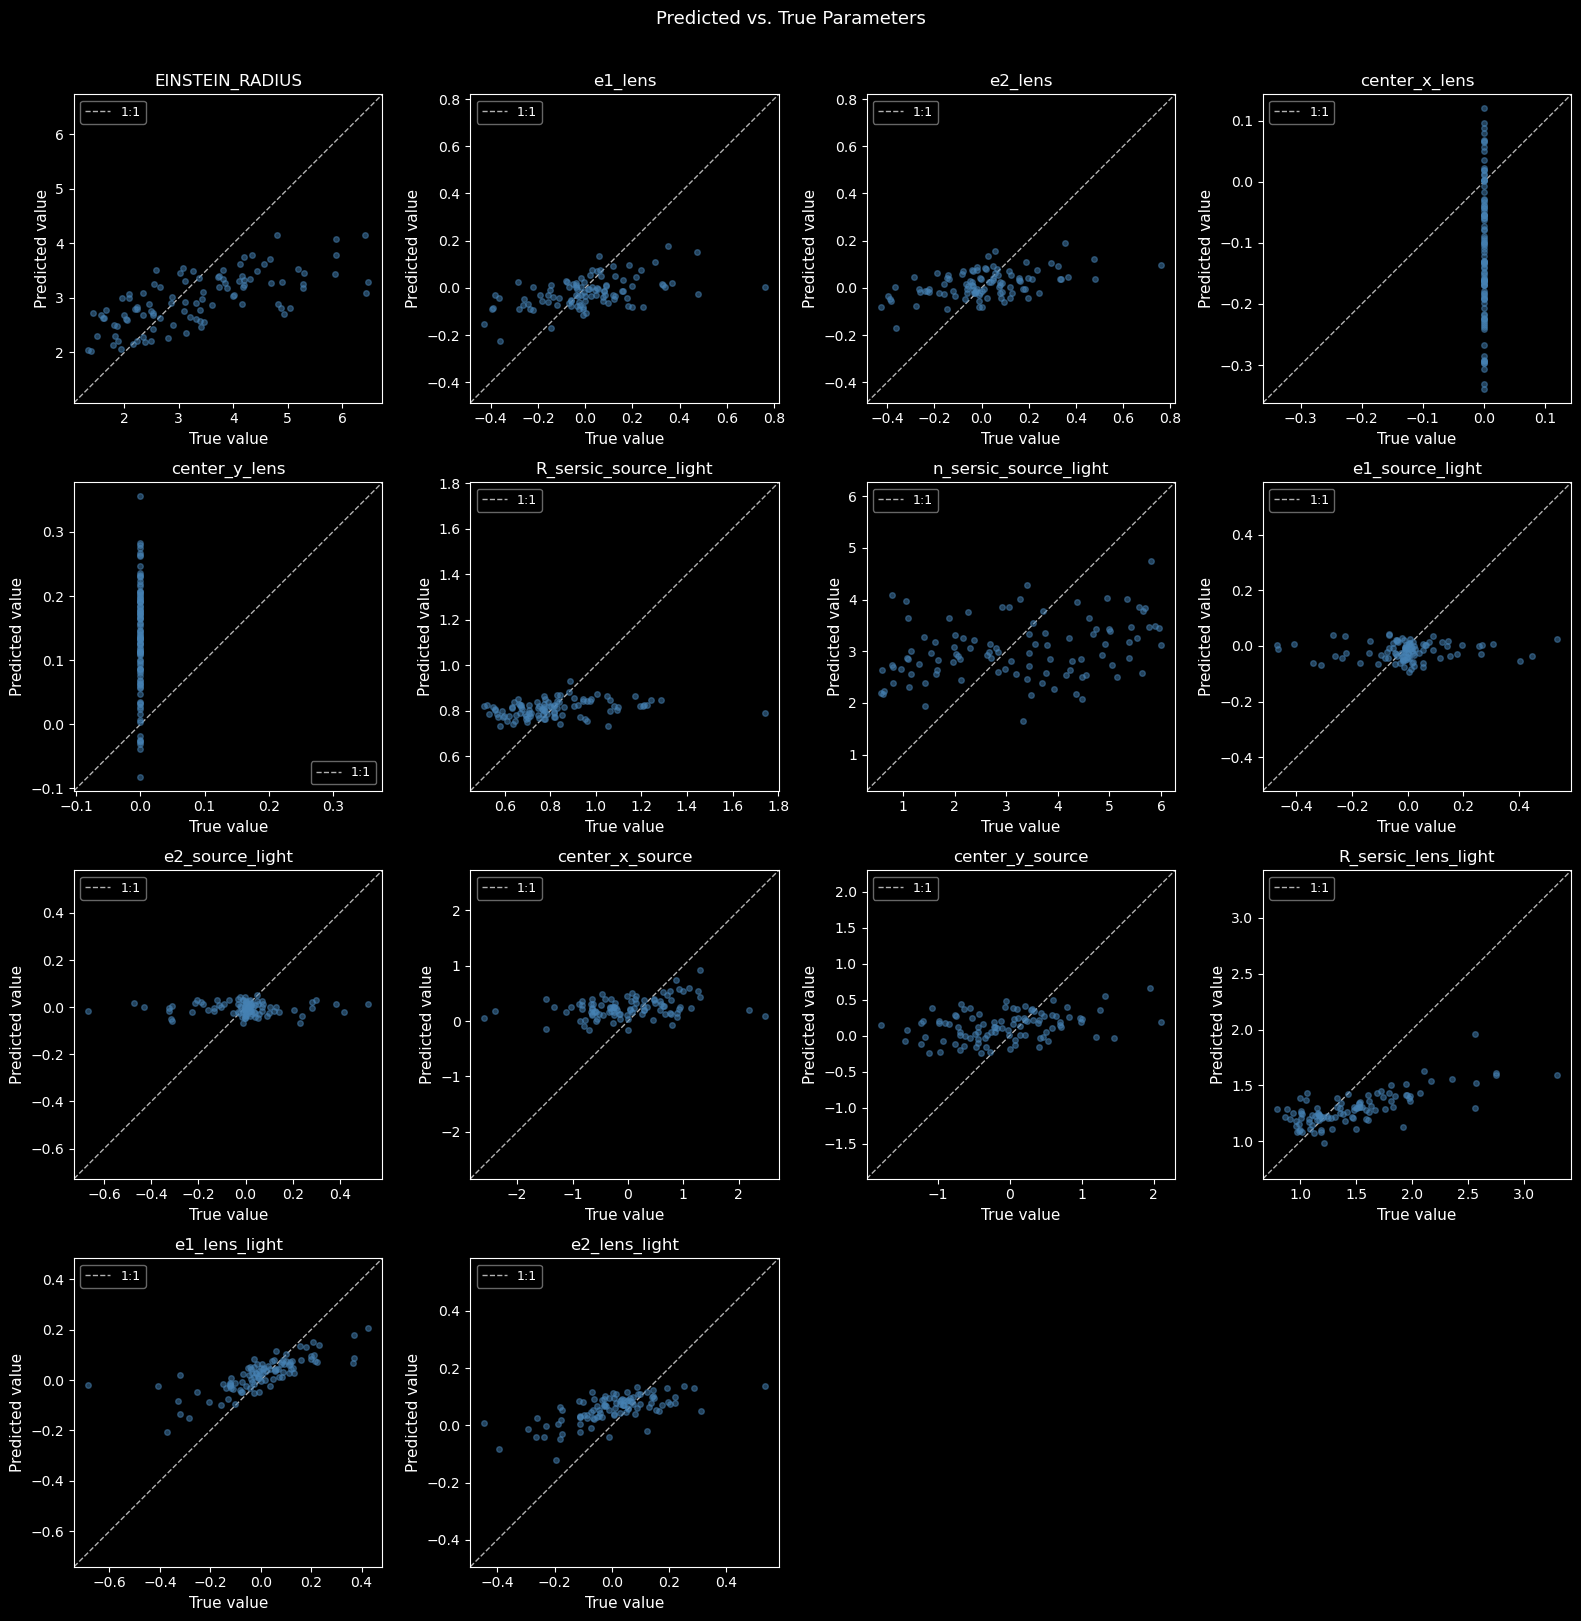

In [24]:
import math

n_cols = 4
n_rows = math.ceil(len(names) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 4, n_rows * 4))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, names)):
    x = np.linspace(min(true_data[name]), max(true_data[name]), 1000)

    # 1:1 reference line
    all_vals = np.concatenate([true_data[name], predicted_data[name]])
    lims = [all_vals.min(), all_vals.max()]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]

    ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.7, label='1:1')
    ax.plot(true_data[name], predicted_data[name], 'o', markersize=4, color='steelblue', alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('True value', fontsize=11)
    ax.set_ylabel('Predicted value', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.legend(fontsize=9, framealpha=0.5)

# Hide unused axes
for ax in axes[len(names):]:
    ax.set_visible(False)

plt.suptitle('Predicted vs. True Parameters', fontsize=13, y=1.01)
plt.tight_layout()

if script:
    plt.savefig('True_Predic_all.png', bbox_inches='tight')
    plt.close()
else:
    plt.show()
